In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import random

print(" Librerías importadas correctamente")

 Librerías importadas correctamente


In [14]:
np.random.seed(42)
random.seed(42)

n = 1_000_000  

influencers = [
    "cancun_vibes", "playadelcarmen_life", "mexico_travel",
    "caribemexicano", "cancun_foodie", "rivieramaya_oficial",
    "cancun_explorer", "tulum_lifestyle", "holbox_paradise",
    "cancun_sunsets"
]

tipos_post = ["foto", "video", "reels", "carrusel", "historia"]

fecha_inicio = datetime(2024, 1, 1)
fecha_fin   = datetime(2025, 1, 1)
rango_dias  = (fecha_fin - fecha_inicio).days

data = {
    "influencer": np.random.choice(influencers, size=n),
    "likes":      np.random.randint(100, 500_000, size=n),
    "comentarios":np.random.randint(10,  50_000,  size=n),
    "fecha": [
        fecha_inicio + timedelta(days=random.randint(0, rango_dias))
        for _ in range(n)
    ],
    "tipo_post":  np.random.choice(tipos_post, size=n),
}

df = pd.DataFrame(data)
print(f" Dataset creado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
df.head()

 Dataset creado: 1,000,000 filas × 5 columnas


,influencer,likes,comentarios,fecha,tipo_post
0,cancun_explorer,411794,10915,2024-11-23,video
1,caribemexicano,309483,32414,2024-02-27,historia
2,tulum_lifestyle,149040,41706,2024-01-13,carrusel
3,cancun_foodie,412269,21808,2024-05-20,historia
4,cancun_explorer,331229,17869,2024-05-05,reels


In [15]:
print(" INFORMACIÓN GENERAL")
print("-" * 40)
print(df.info())

print("\n ESTADÍSTICAS DESCRIPTIVAS")
print(df.describe())

print("\n VALORES NULOS")
print(df.isnull().sum())

 INFORMACIÓN GENERAL
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 5 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   influencer   1000000 non-null  object        
 1   likes        1000000 non-null  int32         
 2   comentarios  1000000 non-null  int32         
 3   fecha        1000000 non-null  datetime64[ns]
 4   tipo_post    1000000 non-null  object        
dtypes: datetime64[ns](1), int32(2), object(2)
memory usage: 30.5+ MB
None

 ESTADÍSTICAS DESCRIPTIVAS
                likes     comentarios                          fecha
count  1000000.000000  1000000.000000                        1000000
mean    250154.242297    25029.294898  2024-07-02 00:23:32.812799232
min        100.000000       10.000000            2024-01-01 00:00:00
25%     125181.750000    12519.000000            2024-04-01 00:00:00
50%     250124.500000 

In [16]:
engagement = df.groupby("influencer").agg(
    total_likes       = ("likes",       "sum"),
    total_comentarios = ("comentarios", "sum"),
    promedio_likes    = ("likes",       "mean"),
    num_publicaciones = ("likes",       "count")
).sort_values("total_likes", ascending=False).reset_index()

print(" TOP 10 INFLUENCERS POR LIKES TOTALES")
print(engagement)

 TOP 10 INFLUENCERS POR LIKES TOTALES
            influencer  total_likes  total_comentarios  promedio_likes  \
0        cancun_foodie  25212291564         2524804273   250913.512510   
1  rivieramaya_oficial  25061659711         2491360830   250767.057344   
2       caribemexicano  25022841217         2506800201   250285.977945   
3        mexico_travel  25019202741         2509868803   249555.660476   
4         cancun_vibes  25016890749         2504505317   249884.039685   
5  playadelcarmen_life  24992849390         2501176081   249806.088916   
6      tulum_lifestyle  24974274699         2488903758   250547.002869   
7      cancun_explorer  24968930769         2497582929   250091.955739   
8      holbox_paradise  24956643363         2499086011   250109.170530   
9       cancun_sunsets  24928658094         2505206695   249581.086622   

   num_publicaciones  
0             100482  
1              99940  
2              99977  
3             100255  
4             100114  
5        

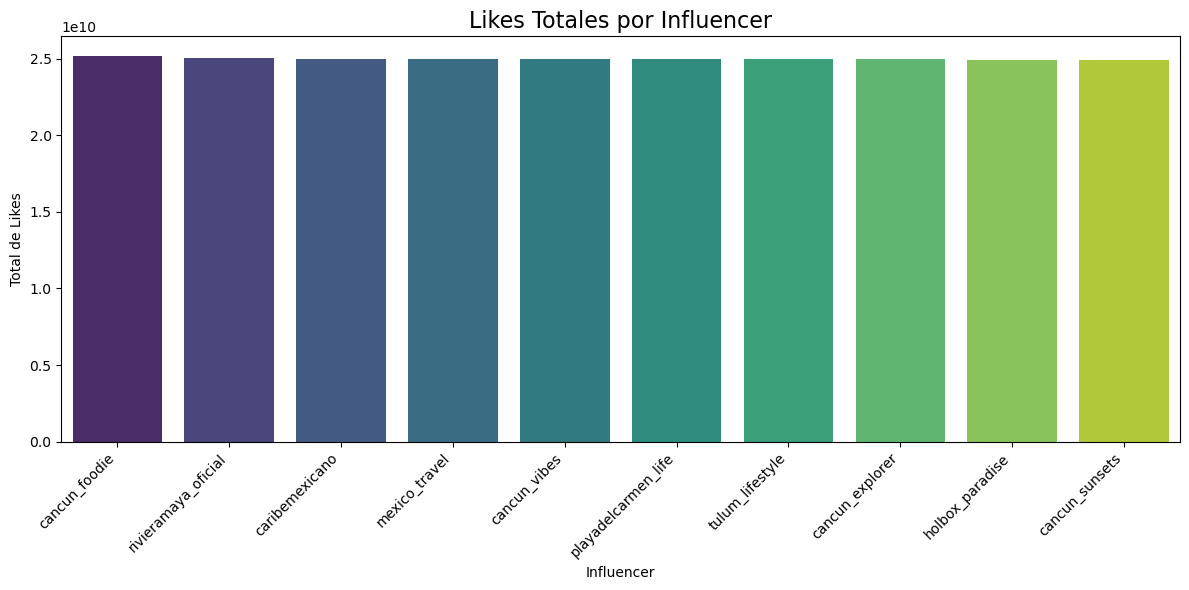

In [17]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=engagement,
    x="influencer",
    y="total_likes",
    hue="influencer",   
    legend=False,       
    palette="viridis"
)
plt.title("Likes Totales por Influencer", fontsize=16)
plt.xlabel("Influencer")
plt.ylabel("Total de Likes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

 ENGAGEMENT PROMEDIO POR TIPO DE POST
  tipo_post  promedio_likes  promedio_comentarios  total_publicaciones
0  historia   250260.773096          25037.482195               200027
1  carrusel   250203.944946          25001.392431               199551
2     reels   250173.492584          25003.991713               199712
3      foto   250091.966784          25040.597485               199876
4     video   250041.590144          25062.777866               200834


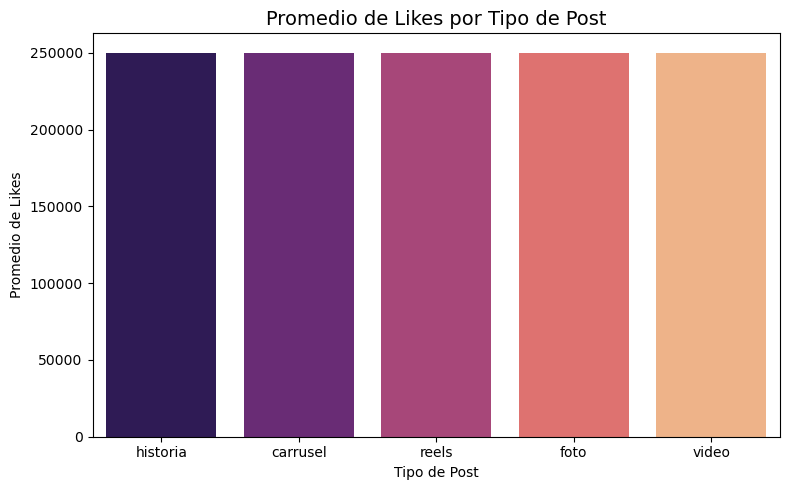

In [18]:
por_tipo = df.groupby("tipo_post").agg(
    promedio_likes       = ("likes",       "mean"),
    promedio_comentarios = ("comentarios", "mean"),
    total_publicaciones  = ("likes",       "count")
).sort_values("promedio_likes", ascending=False).reset_index()

print(" ENGAGEMENT PROMEDIO POR TIPO DE POST")
print(por_tipo)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=por_tipo,
    x="tipo_post",
    y="promedio_likes",
    hue="tipo_post",  
    legend=False,     
    palette="magma"
)
plt.title("Promedio de Likes por Tipo de Post", fontsize=14)
plt.xlabel("Tipo de Post")
plt.ylabel("Promedio de Likes")
plt.tight_layout()
plt.show()

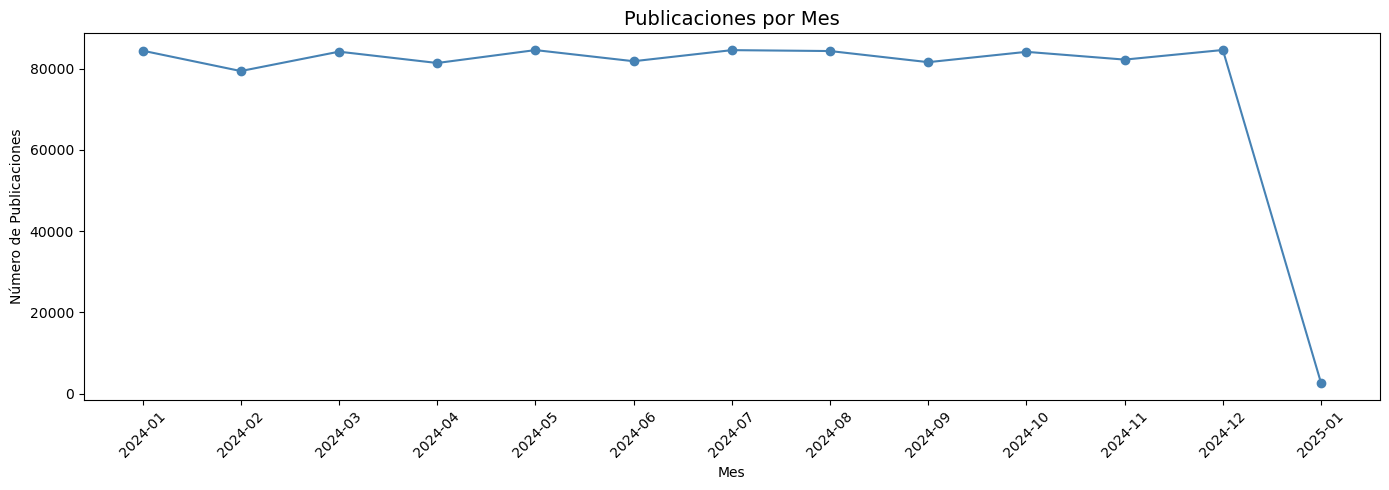

In [19]:
df["mes"] = pd.to_datetime(df["fecha"]).dt.to_period("M")

por_mes = df.groupby("mes").agg(
    publicaciones = ("likes", "count"),
    likes_promedio = ("likes", "mean")
).reset_index()

por_mes["mes_str"] = por_mes["mes"].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(por_mes["mes_str"], por_mes["publicaciones"], marker="o", color="steelblue")
plt.title("Publicaciones por Mes", fontsize=14)
plt.xlabel("Mes")
plt.ylabel("Número de Publicaciones")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
df["engagement_rate"] = (df["likes"] + df["comentarios"]) / 1_000_000 * 100

top_engagement = (
    df.groupby("influencer")["engagement_rate"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
top_engagement.columns = ["influencer", "engagement_rate_promedio"]

print(" TASA DE ENGAGEMENT PROMEDIO POR INFLUENCER")
print(top_engagement)

 TASA DE ENGAGEMENT PROMEDIO POR INFLUENCER
            influencer  engagement_rate_promedio
0        cancun_foodie                 27.604044
1  rivieramaya_oficial                 27.569562
2      tulum_lifestyle                 27.551619
3       caribemexicano                 27.535975
4      holbox_paradise                 27.515438
5      cancun_explorer                 27.510806
6         cancun_vibes                 27.490057
7  playadelcarmen_life                 27.480560
8       cancun_sunsets                 27.466275
9        mexico_travel                 27.459051


In [21]:
print("=" * 50)
print(" INSIGHTS DEL DATASET DE INSTAGRAM - CANCÚN")
print("=" * 50)

mejor = engagement.iloc[0]
print(f"\n Influencer con más likes: {mejor['influencer']}")
print(f"   → {mejor['total_likes']:,} likes totales")

mejor_tipo = por_tipo.iloc[0]
print(f"\n Tipo de post más efectivo: {mejor_tipo['tipo_post']}")
print(f"   → {mejor_tipo['promedio_likes']:,.0f} likes promedio")

mes_pico = por_mes.loc[por_mes["publicaciones"].idxmax()]
print(f"\n Mes con más actividad: {mes_pico['mes_str']}")
print(f"   → {mes_pico['publicaciones']:,} publicaciones")

print(f"\n Total de publicaciones analizadas: {len(df):,}")
print(f" Promedio global de likes: {df['likes'].mean():,.0f}")
print(f" Promedio global de comentarios: {df['comentarios'].mean():,.0f}")

 INSIGHTS DEL DATASET DE INSTAGRAM - CANCÚN

 Influencer con más likes: cancun_foodie
   → 25,212,291,564 likes totales

 Tipo de post más efectivo: historia
   → 250,261 likes promedio

 Mes con más actividad: 2024-12
   → 84,605 publicaciones

 Total de publicaciones analizadas: 1,000,000
 Promedio global de likes: 250,154
 Promedio global de comentarios: 25,029
